<a href="https://colab.research.google.com/github/NikhilMunna/Kriging/blob/master/Variogram_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pylab 
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [0]:
def range_xy(sill, X, Y):
  percent95 = 0.95*sill
  for i in range(len(X)):
    if(Y[i] >= percent95):
      return X[i]
  return X[-1]

def spherical_model(data, X, Y,label="N"):
  nugget=Y[0]
  sill=(data[label]).var()
  a=range_xy(sill,X,Y)
  Z=pd.DataFrame(np.array(np.arange(0, X[-1])))
  Z[(Z.index<=a)]=nugget+(sill-nugget)*(1.5*Z/a-0.5*np.power(Z/a,3))
  Z[(Z.index>a)]=sill
  return np.array(Z)
    
def exponential_model(data, X, Y,label="N"):
  nugget=Y[0]
  sill=(data[label]).var()
  a=range_xy(sill,X,Y)
  Z=pd.DataFrame(np.array(np.arange(0, X[-1])))
  Z=nugget+(sill-nugget)*(1-np.exp(-3*Z/a))
  return np.array(Z)
  
  
def gaussian_model(data, X, Y,label="N"):
  nugget=Y[0]
  sill=(data[label]).var()
  a=range_xy(sill,X,Y)
  Z=pd.DataFrame(np.array(np.arange(0, X[-1])))
  Z=nugget+(sill-nugget)*(1-np.exp(-3*np.square(Z)/np.square(a)))
  return np.array(Z)

def mean_absolute_percentage_error(data, gold_grade='N', estimate='estimate'):
  error_series = (data.apply(lambda row: np.abs((row.gold_grade - row.estimate)/row.gold_grade), axis=1))
  return error_series.sum()*100/len(error_series)

In [0]:
data = pd.read_csv("/content/scaledNForkrig.csv", sep="," , header =None , names = ['X' , 'Y' , 'N' ])
data.head
x_train = data.drop(columns = ['N'])
y_train = data['N']
print(data.head())
print(len(x_train))
print(len(y_train))
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2)

        X       Y        N
0  17.895  73.401  0.63157
1  17.895  73.401  0.65262
2  17.895  73.402  0.39998
3  17.895  73.404  0.82105
4  17.895  73.404  0.88421
25806
25806


In [0]:
sample_train = (pd.DataFrame({'X': x_train['X'], 'Y': x_train['Y'], 'N':y_train})).reset_index(drop=True)
sample_test = (pd.DataFrame({'X': x_test['X'], 'Y': x_test['Y'], 'N':y_test})).reset_index(drop=True)
sample_train.head()

,X,Y,N
0,18.201,74.395,0.13358
1,18.862,75.144,0.11860
2,18.452,74.382,0.19053
3,20.370,73.810,0.13222
4,18.543,75.094,0.22888


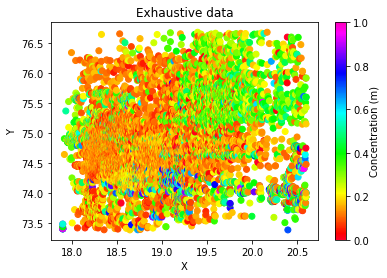

In [0]:
plt.scatter(data['X'], data['Y'], c=data['N'], cmap='gist_rainbow')
cbar= plt.colorbar()
cbar.set_label("Concentration (m)", labelpad=+1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exhaustive data")
plt.show()

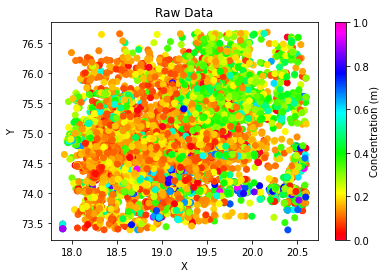

In [0]:
plt.scatter(sample_train['X'], sample_train['Y'], c=sample_train['N'], cmap='gist_rainbow')
cbar= plt.colorbar()
cbar.set_label("Concentration (m)", labelpad=+1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Raw Data")
plt.show()

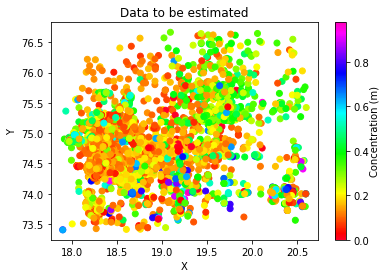

In [0]:
plt.scatter(sample_test['X'], sample_test['Y'], c=sample_test['N'], cmap='gist_rainbow')
cbar= plt.colorbar()
cbar.set_label("Concentration (m)", labelpad=+1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Data to be estimated")
plt.show()

In [0]:
sample_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20644 entries, 0 to 20643
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       20644 non-null  float64
 1   Y       20644 non-null  float64
 2   N       20644 non-null  float64
dtypes: float64(3)
memory usage: 484.0 KB


In [0]:
sample_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5162 entries, 0 to 5161
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       5162 non-null   float64
 1   Y       5162 non-null   float64
 2   N       5162 non-null   float64
dtypes: float64(3)
memory usage: 121.1 KB


In [0]:
sample_train.describe()

,X,Y,N
count,20644.000000,20644.000000,20644.000000
mean,18.803093,74.741058,0.224996
std,0.633928,0.557301,0.153134
min,17.895000,73.384000,0.000000
25%,18.321000,74.378000,0.123030
50%,18.544000,74.696000,0.175410
75%,19.236000,75.092250,0.298220
max,20.598000,76.675000,1.000000


In [0]:
sample_test.describe()

,X,Y,N
count,5162.000000,5162.000000,5162.000000
mean,18.798464,74.749460,0.224641
std,0.630751,0.565559,0.155613
min,17.895000,73.401000,0.000000
25%,18.321250,74.380000,0.122780
50%,18.542000,74.693000,0.172880
75%,19.225750,75.118000,0.285060
max,20.598000,76.667000,0.978610


In [0]:
from collections import defaultdict
def variogram(data, X = "X", Y = "Y", G="N", min_angle=0, angle_tolerance=90, no_of_lags, lag_spacing, lag_tolerance):
    g_values = pd.DataFrame({'distance':[] , 'values':[]})
    x_y_values = defaultdict(lambda:0)
    count = defaultdict(lambda:0)
    for i in range(data.shape[0]):
        if(angle_tolerance >= 90):
            # print(data[X])
            var_data = pd.DataFrame(np.array(data[(data.index > i) & (np.sqrt(np.square(data[X]-data[X][i])+np.square(data[Y]-data[Y][i])) <= no_of_lags*lag_spacing)])).rename(index = str, columns={0:X, 1:Y, 2:'values'})
        elif(min_angle+angle_tolerance > 90):
            var_data = pd.DataFrame(np.array(data[(data.index > i) & (~((np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi > min_angle+angle_tolerance-180) & (np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi < min_angle-angle_tolerance))) & (np.sqrt(np.square(data[X]-data[X][i])+np.square(data[Y]-data[Y][i])) <= no_of_lags*lag_spacing)])).rename(index = str, columns={0:X, 1:Y, 2:'values'})
        elif(min_angle-angle_tolerance < -90):
            var_data = pd.DataFrame(np.array(data[(data.index > i) & (~((np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi > min_angle+angle_tolerance) & (np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi < 180+min_angle-angle_tolerance))) &(np.sqrt(np.square(data[X]-data[X][i])+np.square(data[Y]-data[Y][i])) <= no_of_lags*lag_spacing)])).rename(index = str, columns={0:X, 1:Y, 2:'values'})
        else:
            var_data = pd.DataFrame(np.array(data[(data.index > i) & ((np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi >= min_angle-angle_tolerance) & (np.arctan2(data[Y]-data[Y][i], data[X]-data[X][i])*180/np.pi <= min_angle+angle_tolerance)) & (np.sqrt(np.square(data[X]-data[X][i])+np.square(data[Y]-data[Y][i])) <= no_of_lags*lag_spacing)])).rename(index = str, columns={0:X, 1:Y, 2:'values'})
        var_data[X] -= data[X][i]
        var_data[Y] -= data[Y][i]
        var_data["distance"] = np.linalg.norm(var_data[[X, Y]], axis=1)
        var_data = var_data.drop(columns=[X, Y])
        var_data["values"] = var_data["values"] - data[G][i]
        g_values = g_values.append(var_data, ignore_index = True)
        if(i%100 == 0):
            for j in np.arange(0, no_of_lags*lag_spacing+1, lag_spacing):
                range_array = np.array(g_values[(g_values['distance']>j-lag_tolerance) & (g_values['distance'] <= j+lag_tolerance)]['values'])
                x_y_values[j] += np.sum(np.square(range_array), axis = 0)
                count[j] += range_array.shape[0]
            g_values = pd.DataFrame({'distance':[] , 'values':[]}) 
    x = []
    y = []
    for keys in x_y_values:
        x.append(keys)
        y.append(x_y_values[keys]/(2*count[keys]))
    return(x, y)

SyntaxError: ignored

In [0]:
def covariance_function(nugget, sill, distance, a, model = "spherical"):
  if(model == "spherical"):
    return ((sill-nugget)*(1-1.5*distance/a+0.5*np.power(distance/a,3)))
  elif(model == "gaussian"):
    return ((sill-nugget)*(np.exp(-3*np.square(distance)/np.square(a))))
  elif(model == "exponential"):
    return ((sill-nugget)*(np.exp(-3*distance/a)))
  
count = 0
    
def find_estimate(data, x, y, nugget, a, X='X', Y='Y', G='N', model="spherical", max_points=4, kriging_type="ordinary"):
  points = pd.DataFrame({X:[], Y:[], G:[] , 'distance':[]})
  df1 = pd.DataFrame(np.array(data[(data[X] >= x) & (data[Y] >= y)])).rename(index = str, columns={0:X, 1:Y, 2:G})
  df1["distance"] = np.sqrt(np.square(df1[X]-x)+np.square(df1[Y]-y))
  points = points.append(df1.sort_values(["distance"]).head(n=max_points))
  df1 = pd.DataFrame(np.array(data[(data[X] > x) & (data[Y] < y)])).rename(index = str, columns={0:X, 1:Y, 2:G})
  df1["distance"] = np.sqrt(np.square(df1[X]-x)+np.square(df1[Y]-y))
  points = points.append(df1.sort_values(["distance"]).head(n=max_points))
  df1 = pd.DataFrame(np.array(data[(data[X] < x) & (data[Y] < y)])).rename(index = str, columns={0:X, 1:Y, 2:G})
  df1["distance"] = np.sqrt(np.square(df1[X]-x)+np.square(df1[Y]-y))
  points = points.append(df1.sort_values(["distance"]).head(n=max_points))
  df1 = pd.DataFrame(np.array(data[(data[X] < x) & (data[Y] > y)])).rename(index = str, columns={0:X, 1:Y, 2:G})
  df1["distance"] = np.sqrt(np.square(df1[X]-x)+np.square(df1[Y]-y))
  points = points.append(df1.sort_values(["distance"]).head(n=max_points))
  distances = pd.merge(pd.DataFrame({'key':1, 'X1':points[X], 'Y1':points[Y]}), pd.DataFrame({'key':1, 'X2':points[X], 'Y2':points[Y]}))
  distances['distance'] = np.sqrt(np.square(distances['X1']-distances['X2'])+np.square(distances['Y1']-distances['Y2']))
  dist_length = len(distances)
  if(kriging_type == "ordinary"):
    self_cov_matrix = np.pad(covariance_function(nugget, (data[G]).var(), np.array(points['distance']),  a, model), (0,1), 'constant', constant_values=(0, 1))
  elif(kriging_type == "block"):
    block_points = (pd.merge(pd.DataFrame({"key":1, "X":np.array(range(int(x)-50,int(x)+50))}), pd.DataFrame({"key":1, "Y":np.array(range(int(y)-50,int(y)+50))}), on='key'))
    b_shape = block_points.shape[0]
    p_shape = points.shape[0]
    block_points = (pd.merge(pd.DataFrame({"key":1, "X1":block_points[X], "Y1":block_points[Y]}), pd.DataFrame({"key":1, "X2":points[X], "Y2":points[Y]}), on='key'))
    block_points["distance"] = block_points.apply(lambda row: np.sqrt(np.square(row.X1-row.X2)+np.square(row.Y1-row.Y2)), axis = 1)
    self_cov_matrix = np.pad(np.average(covariance_function(nugget, (data[G]).var(), np.array(block_points["distance"]).reshape(p_shape, b_shape), a, model), axis = 1), (0,1), 'constant', constant_values=(0, 1))
  cov_matrix = np.pad(covariance_function(nugget, (data[G]).var(), (np.array(distances['distance'])).reshape((int(np.sqrt(dist_length)), int(np.sqrt(dist_length)))), a, model), ((0, 1), (0, 1)), 'constant', constant_values=((0, 1), (0, 1)))
  cov_matrix[-1, -1] = 0
  #print(cov_matrix)
  #print(self_cov_matrix)
  #print(cov_matrix.shape)
  #print(self_cov_matrix.shape)
  weights = np.dot(np.linalg.pinv(cov_matrix), self_cov_matrix) 
  #print(weights)
  #print(x, y)
  return(max(0, np.dot(weights[:-1], np.array(points[G]))))
  
  
  
def kriging(sample_train, sample_test, nugget, a, X='X', Y='Y', G='N', model="spherical", kriging_type="ordinary"):
  sample_test['estimate'] = sample_test.apply(lambda row: find_estimate(sample_train, row.X, row.Y, nugget, a, kriging_type=kriging_type), axis=1)
  return sample_test
  
  

In [0]:
start = time.time()
[X, Y] = variogram(sample_train, no_of_lags=10, lag_spacing = (4.12343509710047/10)/2, lag_tolerance=(4.12343509710047/10)/4 )
plt.scatter(X, Y)
plt.plot(spherical_model(sample_train, X, Y), 'g-')
#plt.plot(exponential_model(sample_train, X, Y), 'b-')
#plt.plot(gaussian_model(sample_train, X, Y), 'r-')
plt.xlabel("Distance")
plt.ylabel("Variogram")
plt.title("Variogram")
print("Time taken: ", time.time()-start)

In [0]:
start = time.time()
print(find_estimate(sample_train, -1000, -25000, Y[0], range_xy(data['N'].var(), X, Y), model="spherical"))
print("Time taken: ", time.time()-start)

LinAlgError: ignored

In [0]:
#sample_train.var()
sample_test = kriging(sample_train, sample_test, Y[0], range_xy(sample_train['gold_grade'].var(), X, Y), model="exponential")
sample_test

In [0]:
plt.scatter(sample_test['X'], sample_test['Y'], c=sample_test['estimate'], cmap='gist_rainbow')
cbar= plt.colorbar()
cbar.set_label("concentration (m)", labelpad=+1)

In [0]:
print("Mean Absolute Error: ", mean_absolute_error(sample_test['gold_grade'], sample_test['estimate']))
print("Mean Square Error", mean_squared_error(sample_test['gold_grade'], sample_test['estimate']))
print("Score: ", r2_score(sample_test['gold_grade'], sample_test['estimate']))
print("Mean Absolute Percentage Error: ", mean_absolute_percentage_error(sample_test))

In [0]:
[X, Y] = variogram(data, min_angle = 90, angle_tolerance = 30, no_of_lags=20, lag_spacing = 50, lag_tolerance = 25)
plt.scatter(X, Y)
plt.xlabel("Distance")
plt.ylabel("Variogram")
plt.title("Variogram")